# Лабораторная работа № 4
## Дисциплина: Computer Vision (ANL7306)
### Тема: «Классическая сегментация изображений: Watershed, GrabCut, Superpixels»

---

### 1. Цель работы
Освоить три фундаментальных классических алгоритма сегментации изображений:
1. Сегментацию методом водораздела (**Watershed**) с использованием маркеров через морфологию и преобразование расстояний;
2. Интерактивную сегментацию объект/фон методом разреза графа (**GrabCut**);
3. Построение компактных суперпикселей алгоритмом **SLIC** (*Simple Linear Iterative Clustering*).

Научиться подбирать параметры каждого алгоритма, оценивать вычислительную сложность и осознанно выбирать метод под конкретную прикладную задачу компьютерного зрения.

---

### 2. Краткие теоретические сведения

#### 2.1 Watershed (Метод водораздела)
Величина градиента яркости $|\nabla I(x, y)|$ (или инвертированное преобразование расстояния) интерпретируется как топографический рельеф местности: однородные области образуют низины (бассейны), а границы объектов — горные хребты. Алгоритм моделирует «затопление» рельефа водой одновременно из заданных начальных маркеров. В местах столкновения водных потоков из разных бассейнов возводятся границы-плотины. Для предотвращения перерасчленения (over-segmentation) маркеры вычисляются предварительно через пороговую фильтрацию карты расстояний (`cv2.distanceTransform`) и морфологические операции.

#### 2.2 GrabCut (Сегментация через разрез графа)
Изображение представляется как неориентированный граф $G = (V, E)$, где каждый пиксель — вершина, соединенная n-связями с соседями, а также t-связями с двумя терминалами: Источником (Source — Объект) и Стоком (Sink — Фон). Энергия Гиббса:
$$E(L) = U(L) + V(L)$$
состоит из регионального члена (штраф за несоответствие цвета пикселя смеси гауссиан GMM для фона/объекта) и граничного члена (штраф за разрыв соседних пикселей схожего цвета). Задача сводится к поиску минимального разреза графа (**Min-Cut**), который по теореме Форда–Фалкерсона эквивалентен максимальному потоку (**Max-Flow**).

#### 2.3 Superpixels (Алгоритм SLIC)
SLIC выполняет локальную кластеризацию k-средних в 5-мерном пространстве $[L, a, b, x, y]$, объединяя цветовое сходство в перцептивно равномерном пространстве CIELAB и геометрическую близость пикселей. Параметр `region_size` определяет номинальный шаг сетки кластеров, а суперпиксели служат атомарными примитивами, сокращающими размерность последующей обработки графов на порядки.


In [1]:
import time
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Графические настройки
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 11

print(f"OpenCV версия: {cv2.__version__}")
print(f"Наличие модуля cv2.ximgproc: {hasattr(cv2, 'ximgproc')}")


OpenCV версия: 5.0.0
Наличие модуля cv2.ximgproc: True


---
## Задание 1. Watershed: разделение слипшихся объектов

**План выполнения:**
1. Создать синтетическое изображение с 8 перекрывающимися и слипшимися округлыми объектами (монеты / клетки).
2. Построить бинарную маску и вычислить карту расстояний `cv2.distanceTransform`.
3. Сформировать маркеры объектов через пороговую обработку distance transform и маркер фона через морфологическое расширение.
4. Применить алгоритм `cv2.watershed()` и визуализировать границы сегментов.
5. Провести эксперимент с **ДВУМЯ** разными порогами: заниженным (0.35 * Max) и оптимальным (0.70 * Max), сопоставив количество найденных сегментов.


In [2]:
# 1. Создание синтетического изображения со слипшимися объектами
canvas_h, canvas_w = 520, 680
img_synth = np.zeros((canvas_h, canvas_w, 3), dtype=np.uint8)
img_synth[:] = (245, 245, 248)  # Светлый фон

circles_spec = [
    (130, 140, 48, (70, 130, 180)),
    (208, 148, 46, (75, 135, 185)),
    (286, 152, 48, (70, 130, 180)),
    (465, 145, 52, (80, 150, 140)),
    (548, 155, 48, (85, 155, 145)),
    (210, 365, 52, (180, 120, 70)),
    (294, 375, 50, (185, 125, 75)),
    (500, 365, 42, (150, 90, 140))
]

for (cx, cy, r, col) in circles_spec:
    cv2.circle(img_synth, (cx, cy), r, col, -1, lineType=cv2.LINE_AA)
    cv2.circle(img_synth, (cx, cy), r, (40, 40, 50), 2, lineType=cv2.LINE_AA)

img_synth_rgb = cv2.cvtColor(img_synth, cv2.COLOR_BGR2RGB)
img_synth_gray = cv2.cvtColor(img_synth, cv2.COLOR_BGR2GRAY)

# 2. Бинарная маска и Distance Transform
_, binary_mask = cv2.threshold(img_synth_gray, 220, 255, cv2.THRESH_BINARY_INV)

kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel, iterations=2)
sure_bg = cv2.dilate(opening, kernel, iterations=3)

dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
max_dist = dist_transform.max()
print(f"Максимальное расстояние Distance Transform: {max_dist:.2f} px")

# 3. Применение Watershed с двумя порогами (заниженный 0.35 vs оптимальный 0.70)
threshold_ratios = [0.35, 0.70]
watershed_results = {}

for ratio in threshold_ratios:
    thresh_val = ratio * max_dist
    _, sure_fg = cv2.threshold(dist_transform, thresh_val, 255, cv2.THRESH_BINARY)
    sure_fg = np.uint8(sure_fg)

    unknown = cv2.subtract(sure_bg, sure_fg)
    num_markers, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    markers_ws = markers.copy()
    cv2.watershed(img_synth.copy(), markers_ws)

    img_result = img_synth_rgb.copy()
    boundary_mask = np.uint8(markers_ws == -1)
    boundary_dilated = cv2.dilate(boundary_mask, np.ones((3, 3), np.uint8), iterations=1)
    img_result[boundary_dilated == 1] = [255, 0, 0]  # Яркие красные линии границы

    unique_labels = np.unique(markers_ws)
    detected_objects = len(unique_labels[(unique_labels > 1)])

    watershed_results[ratio] = {
        'threshold_val': thresh_val,
        'sure_fg': sure_fg,
        'markers_init': markers,
        'result_img': img_result,
        'num_fg_markers': num_markers - 1,
        'detected_objects': detected_objects
    }

    print(f"Порог {ratio:.2f} * Max ({thresh_val:.1f} px): маркеров = {num_markers - 1}, итоговых сегментов = {detected_objects}")


Максимальное расстояние Distance Transform: 53.33 px
Порог 0.35 * Max (18.7 px): маркеров = 4, итоговых сегментов = 4
Порог 0.70 * Max (37.3 px): маркеров = 8, итоговых сегментов = 8


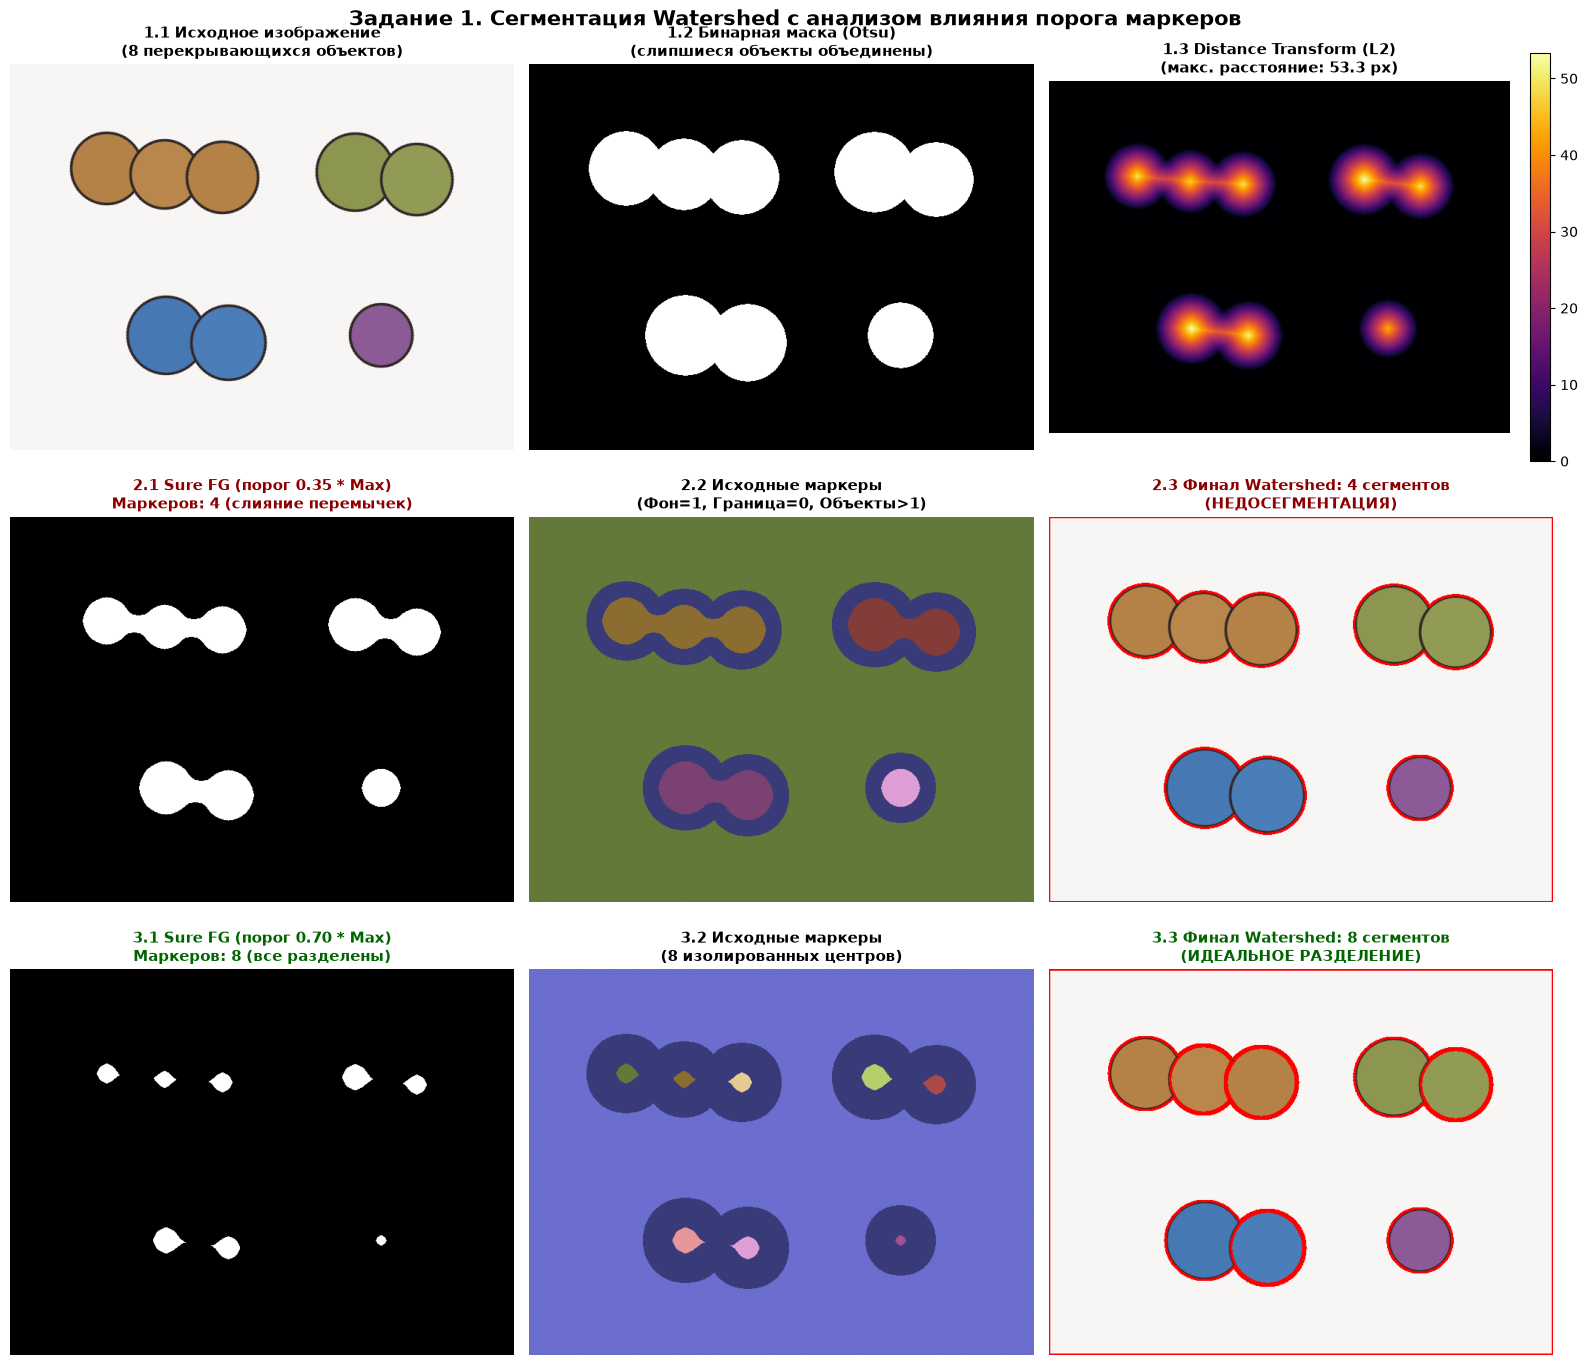

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))

# Ряд 1: Базовые этапы
axes[0, 0].imshow(img_synth_rgb)
axes[0, 0].set_title("1.1 Исходное изображение\n(8 перекрывающихся объектов)", fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(binary_mask, cmap='gray')
axes[0, 1].set_title("1.2 Бинарная маска (Otsu)\n(слипшиеся объекты объединены)", fontweight='bold')
axes[0, 1].axis('off')

im_dist = axes[0, 2].imshow(dist_transform, cmap='inferno')
axes[0, 2].set_title(f"1.3 Distance Transform (L2)\n(макс. расстояние: {max_dist:.1f} px)", fontweight='bold')
axes[0, 2].axis('off')
fig.colorbar(im_dist, ax=axes[0, 2], fraction=0.046, pad=0.04)

# Ряд 2: Заниженный порог (0.35)
res_low = watershed_results[0.35]
axes[1, 0].imshow(res_low['sure_fg'], cmap='gray')
axes[1, 0].set_title(f"2.1 Sure FG (порог 0.35 * Max)\nМаркеров: {res_low['num_fg_markers']} (слияние перемычек)", fontweight='bold', color='darkred')
axes[1, 0].axis('off')

axes[1, 1].imshow(res_low['markers_init'], cmap='tab20b')
axes[1, 1].set_title("2.2 Исходные маркеры\n(Фон=1, Граница=0, Объекты>1)", fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(res_low['result_img'])
axes[1, 2].set_title(f"2.3 Финал Watershed: {res_low['detected_objects']} сегментов\n(НЕДОСЕГМЕНТАЦИЯ)", fontweight='bold', color='darkred')
axes[1, 2].axis('off')

# Ряд 3: Оптимальный порог (0.70)
res_high = watershed_results[0.70]
axes[2, 0].imshow(res_high['sure_fg'], cmap='gray')
axes[2, 0].set_title(f"3.1 Sure FG (порог 0.70 * Max)\nМаркеров: {res_high['num_fg_markers']} (все разделены)", fontweight='bold', color='darkgreen')
axes[2, 0].axis('off')

axes[2, 1].imshow(res_high['markers_init'], cmap='tab20b')
axes[2, 1].set_title("3.2 Исходные маркеры\n(8 изолированных центров)", fontweight='bold')
axes[2, 1].axis('off')

axes[2, 2].imshow(res_high['result_img'])
axes[2, 2].set_title(f"3.3 Финал Watershed: {res_high['detected_objects']} сегментов\n(ИДЕАЛЬНОЕ РАЗДЕЛЕНИЕ)", fontweight='bold', color='darkgreen')
axes[2, 2].axis('off')

plt.suptitle("Задание 1. Сегментация Watershed с анализом влияния порога маркеров", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


**Вывод по Заданию 1:**
- **Заниженный порог ($0.35 \cdot \text{Max}$)**: перешейки между близко расположенными соприкасающимися телами не успевают отфильтроваться, что объединяет маркеры смежных объектов в единую связную область. В результате алгоритм Watershed находит лишь **4 сегмента вместо 8** (недосегментация / under-segmentation).
- **Оптимальный порог ($0.70 \cdot \text{Max}$)**: значение отсекает перемычки, локализуя маркеры строго вблизи локальных максимумов расстояния (в геометрических центрах каждого из кругов). В итоге генерируются ровно **8 изолированных маркеров**, и алгоритм Watershed безошибочно возводит делящие границы-водоразделы между всеми соприкасающимися объектами.


---
## Задание 2. GrabCut: отделение объекта от фона

**План выполнения:**
1. Загрузить изображение с выраженным объектом (`photo.jpg` — котёнок).
2. Задать корректный прямоугольник `rect_correct`, полностью охватывающий объект с небольшим отступом.
3. Применить алгоритм `cv2.grabCut()` в режиме `GC_INIT_WITH_RECT` и получить бинарную маску переднего плана.
4. Задать намеренно усеченный прямоугольник `rect_bad`, срезающий существенные части объекта (уши, голову, лапку), и повторить сегментацию.
5. Сравнить результаты и дать математическое обоснование невозможности восстановления срезанных участков.


In [4]:
img_cat = cv2.imread('photo.jpg')
cat_h, cat_w, _ = img_cat.shape
img_cat_rgb = cv2.cvtColor(img_cat, cv2.COLOR_BGR2RGB)

# 1. Корректный прямоугольник (полный охват)
rect_correct = (370, 110, 315, 550)

# 2. Намеренно усеченный прямоугольник (срезает уши и левый бок)
rect_bad = (430, 240, 200, 420)

def apply_grabcut(img_bgr, rect, num_iters=5):
    mask = np.zeros(img_bgr.shape[:2], np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)

    t0 = time.time()
    cv2.grabCut(img_bgr, mask, rect, bgd_model, fgd_model, num_iters, cv2.GC_INIT_WITH_RECT)
    elapsed = time.time() - t0

    bin_mask = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 1, 0).astype('uint8')
    fg_white = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()
    fg_white[bin_mask == 0] = [255, 255, 255]

    return {
        'mask_raw': mask,
        'bin_mask': bin_mask,
        'fg_white': fg_white,
        'time': elapsed,
        'fg_pixels': int(np.sum(bin_mask))
    }

res_grabcut_corr = apply_grabcut(img_cat, rect_correct, num_iters=5)
res_grabcut_bad = apply_grabcut(img_cat, rect_bad, num_iters=5)

loss_pixels = res_grabcut_corr['fg_pixels'] - res_grabcut_bad['fg_pixels']
loss_pct = (loss_pixels / res_grabcut_corr['fg_pixels']) * 100

print(f"Корректный Box: пикселей объекта = {res_grabcut_corr['fg_pixels']:,}, время = {res_grabcut_corr['time']:.2f} с")
print(f"Обрезанный Box: пикселей объекта = {res_grabcut_bad['fg_pixels']:,}, время = {res_grabcut_bad['time']:.2f} с")
print(f"Потеря информации: {loss_pixels:,} пикселей ({loss_pct:.1f}% площади объекта)")


Корректный Box: пикселей объекта = 106,360, время = 0.66 с
Обрезанный Box: пикселей объекта = 54,605, время = 0.57 с
Потеря информации: 51,755 пикселей (48.7% площади объекта)


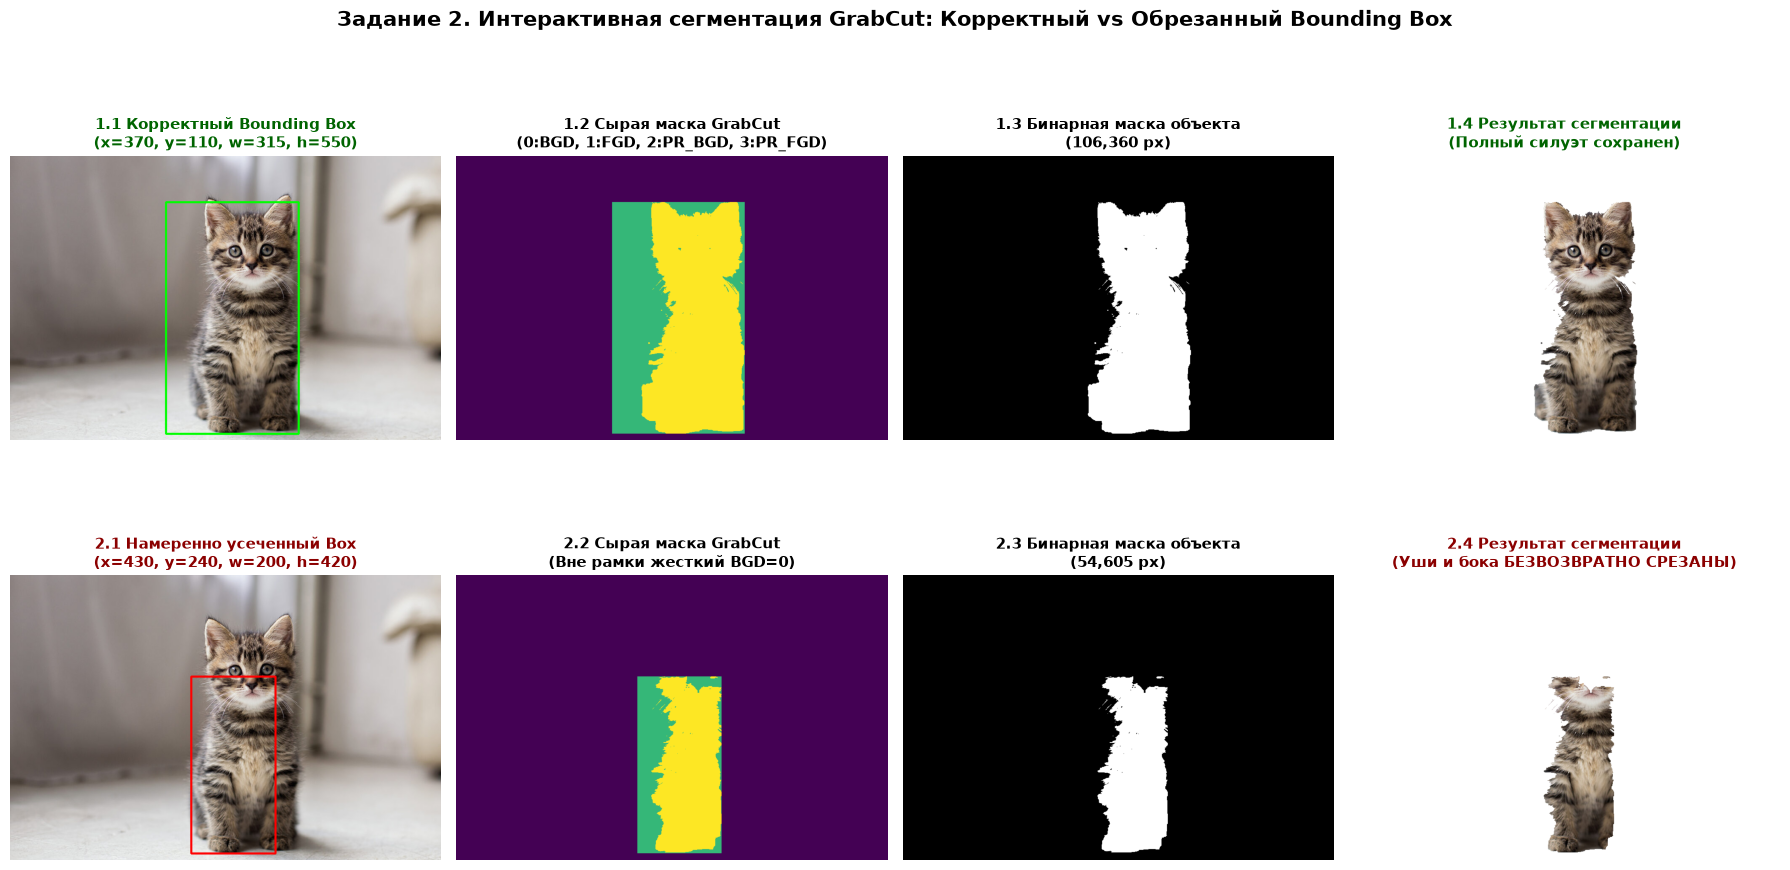

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

# Подготовка рамок
img_rect_corr = img_cat_rgb.copy()
rx, ry, rw, rh = rect_correct
cv2.rectangle(img_rect_corr, (rx, ry), (rx + rw, ry + rh), (0, 255, 0), 4)

img_rect_bad = img_cat_rgb.copy()
bx, by, bw, bh = rect_bad
cv2.rectangle(img_rect_bad, (bx, by), (bx + bw, by + bh), (255, 0, 0), 4)

# Ряд 1: Корректный прямоугольник
axes[0, 0].imshow(img_rect_corr)
axes[0, 0].set_title(f"1.1 Корректный Bounding Box\n(x={rx}, y={ry}, w={rw}, h={rh})", fontweight='bold', color='darkgreen')
axes[0, 0].axis('off')

axes[0, 1].imshow(res_grabcut_corr['mask_raw'], cmap='viridis')
axes[0, 1].set_title("1.2 Сырая маска GrabCut\n(0:BGD, 1:FGD, 2:PR_BGD, 3:PR_FGD)", fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(res_grabcut_corr['bin_mask'] * 255, cmap='gray')
axes[0, 2].set_title(f"1.3 Бинарная маска объекта\n({res_grabcut_corr['fg_pixels']:,} px)", fontweight='bold')
axes[0, 2].axis('off')

axes[0, 3].imshow(res_grabcut_corr['fg_white'])
axes[0, 3].set_title("1.4 Результат сегментации\n(Полный силуэт сохранен)", fontweight='bold', color='darkgreen')
axes[0, 3].axis('off')

# Ряд 2: Обрезанный прямоугольник
axes[1, 0].imshow(img_rect_bad)
axes[1, 0].set_title(f"2.1 Намеренно усеченный Box\n(x={bx}, y={by}, w={bw}, h={bh})", fontweight='bold', color='darkred')
axes[1, 0].axis('off')

axes[1, 1].imshow(res_grabcut_bad['mask_raw'], cmap='viridis')
axes[1, 1].set_title("2.2 Сырая маска GrabCut\n(Вне рамки жесткий BGD=0)", fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(res_grabcut_bad['bin_mask'] * 255, cmap='gray')
axes[1, 2].set_title(f"2.3 Бинарная маска объекта\n({res_grabcut_bad['fg_pixels']:,} px)", fontweight='bold')
axes[1, 2].axis('off')

axes[1, 3].imshow(res_grabcut_bad['fg_white'])
axes[1, 3].set_title("2.4 Результат сегментации\n(Уши и бока БЕЗВОЗВРАТНО СРЕЗАНЫ)", fontweight='bold', color='darkred')
axes[1, 3].axis('off')

plt.suptitle("Задание 2. Интерактивная сегментация GrabCut: Корректный vs Обрезанный Bounding Box", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


**Объяснение, почему GrabCut не смог восстановить обрезанную часть объекта:**
1. **Жесткая фиксация внешних меток:** При вызове режима `cv2.GC_INIT_WITH_RECT` все пиксели строго за пределами ограничивающей рамки инициализируются детерминированной меткой `cv2.GC_BGD` (100% фоновый терминал $T$). Вес ребра от этих пикселей к стоку принимается бесконечным ($\infty$), поэтому никакой минимальный разрез ни при каких обстоятельствах не может перенести их в класс переднего плана.
2. **Исключение из цикла оптимизации:** Алгоритм Graph Cut итеративно переопределяет метки **исключительно** для пикселей внутри рамки (которые инициализированы как `GC_PR_FGD` / вероятный передний план). Область снаружи вообще не участвует в оптимизации меток.
3. **Загрязнение модели фона (GMM Background Poisoning):** Поскольку уши и шерсть, оказавшиеся вне рамки, объявлены фоном, их цветовые векторы поступают в обучающую выборку гауссовой смеси фона ($GMM_{bgd}$). В результате модель фона «учится» считать эти цвета фоновыми и начинает ошибочно вырезать схожие цветовые участки даже внутри допустимой рамки!


---
## Задание 3. Superpixels (SLIC): построение и анализ

**План выполнения:**
1. Построить суперпиксели с помощью `cv2.ximgproc.createSuperpixelSLIC()` для трёх значений `region_size` (10, 25, 50).
2. Отобразить границы суперпикселей поверх исходного изображения (`getLabelContourMask()`).
3. Построить мозаику средних цветов, подтверждающую высокое качество локальной аппроксимации.
4. Замерить время работы и составить сводную таблицу характеристик с анализом выигрыша в вычислительной сложности.


In [6]:
total_pixels = cat_h * cat_w
region_sizes = [10, 25, 50]
slic_experiments = {}

for r_size in region_sizes:
    slic = cv2.ximgproc.createSuperpixelSLIC(
        img_cat,
        algorithm=cv2.ximgproc.SLICO,
        region_size=r_size,
        ruler=10.0
    )

    t_start = time.time()
    slic.iterate(num_iterations=10)
    t_elapsed = (time.time() - t_start) * 1000

    slic.enforceLabelConnectivity()

    num_sp = slic.getNumberOfSuperpixels()
    labels = slic.getLabels()
    contour_mask = slic.getLabelContourMask()

    img_with_contours = img_cat_rgb.copy()
    img_with_contours[contour_mask == 255] = [0, 255, 255]

    mosaic = np.zeros_like(img_cat_rgb)
    labels_flat = labels.ravel()
    counts = np.bincount(labels_flat)
    counts[counts == 0] = 1

    for channel in range(3):
        ch_flat = img_cat_rgb[:, :, channel].ravel()
        sums = np.bincount(labels_flat, weights=ch_flat)
        means = (sums / counts).astype(np.uint8)
        mosaic[:, :, channel] = means[labels]

    compression_ratio = total_pixels / num_sp

    slic_experiments[r_size] = {
        'num_sp': num_sp,
        'time_ms': t_elapsed,
        'compression': compression_ratio,
        'contours_img': img_with_contours,
        'mosaic': mosaic
    }

# Вывод сводной таблицы
print(f"Всего пикселей изображения: {total_pixels:,} ({cat_w}x{cat_h})\n")
print(f"{'region_size':<12} | {'Суперпикселей':<15} | {'Время SLIC (мс)':<17} | {'Степень сжатия':<20}")
print("-" * 72)
for r_size in region_sizes:
    exp = slic_experiments[r_size]
    print(f"{r_size:<12} | {exp['num_sp']:<15} | {exp['time_ms']:<17.2f} | {exp['compression']:<20.1f}x")
print("-" * 72)


Всего пикселей изображения: 692,224 (1024x676)

region_size  | Суперпикселей   | Время SLIC (мс)   | Степень сжатия      
------------------------------------------------------------------------
10           | 6905            | 315.79            | 100.2               x
25           | 1092            | 246.11            | 633.9               x
50           | 275             | 177.41            | 2517.2              x
------------------------------------------------------------------------


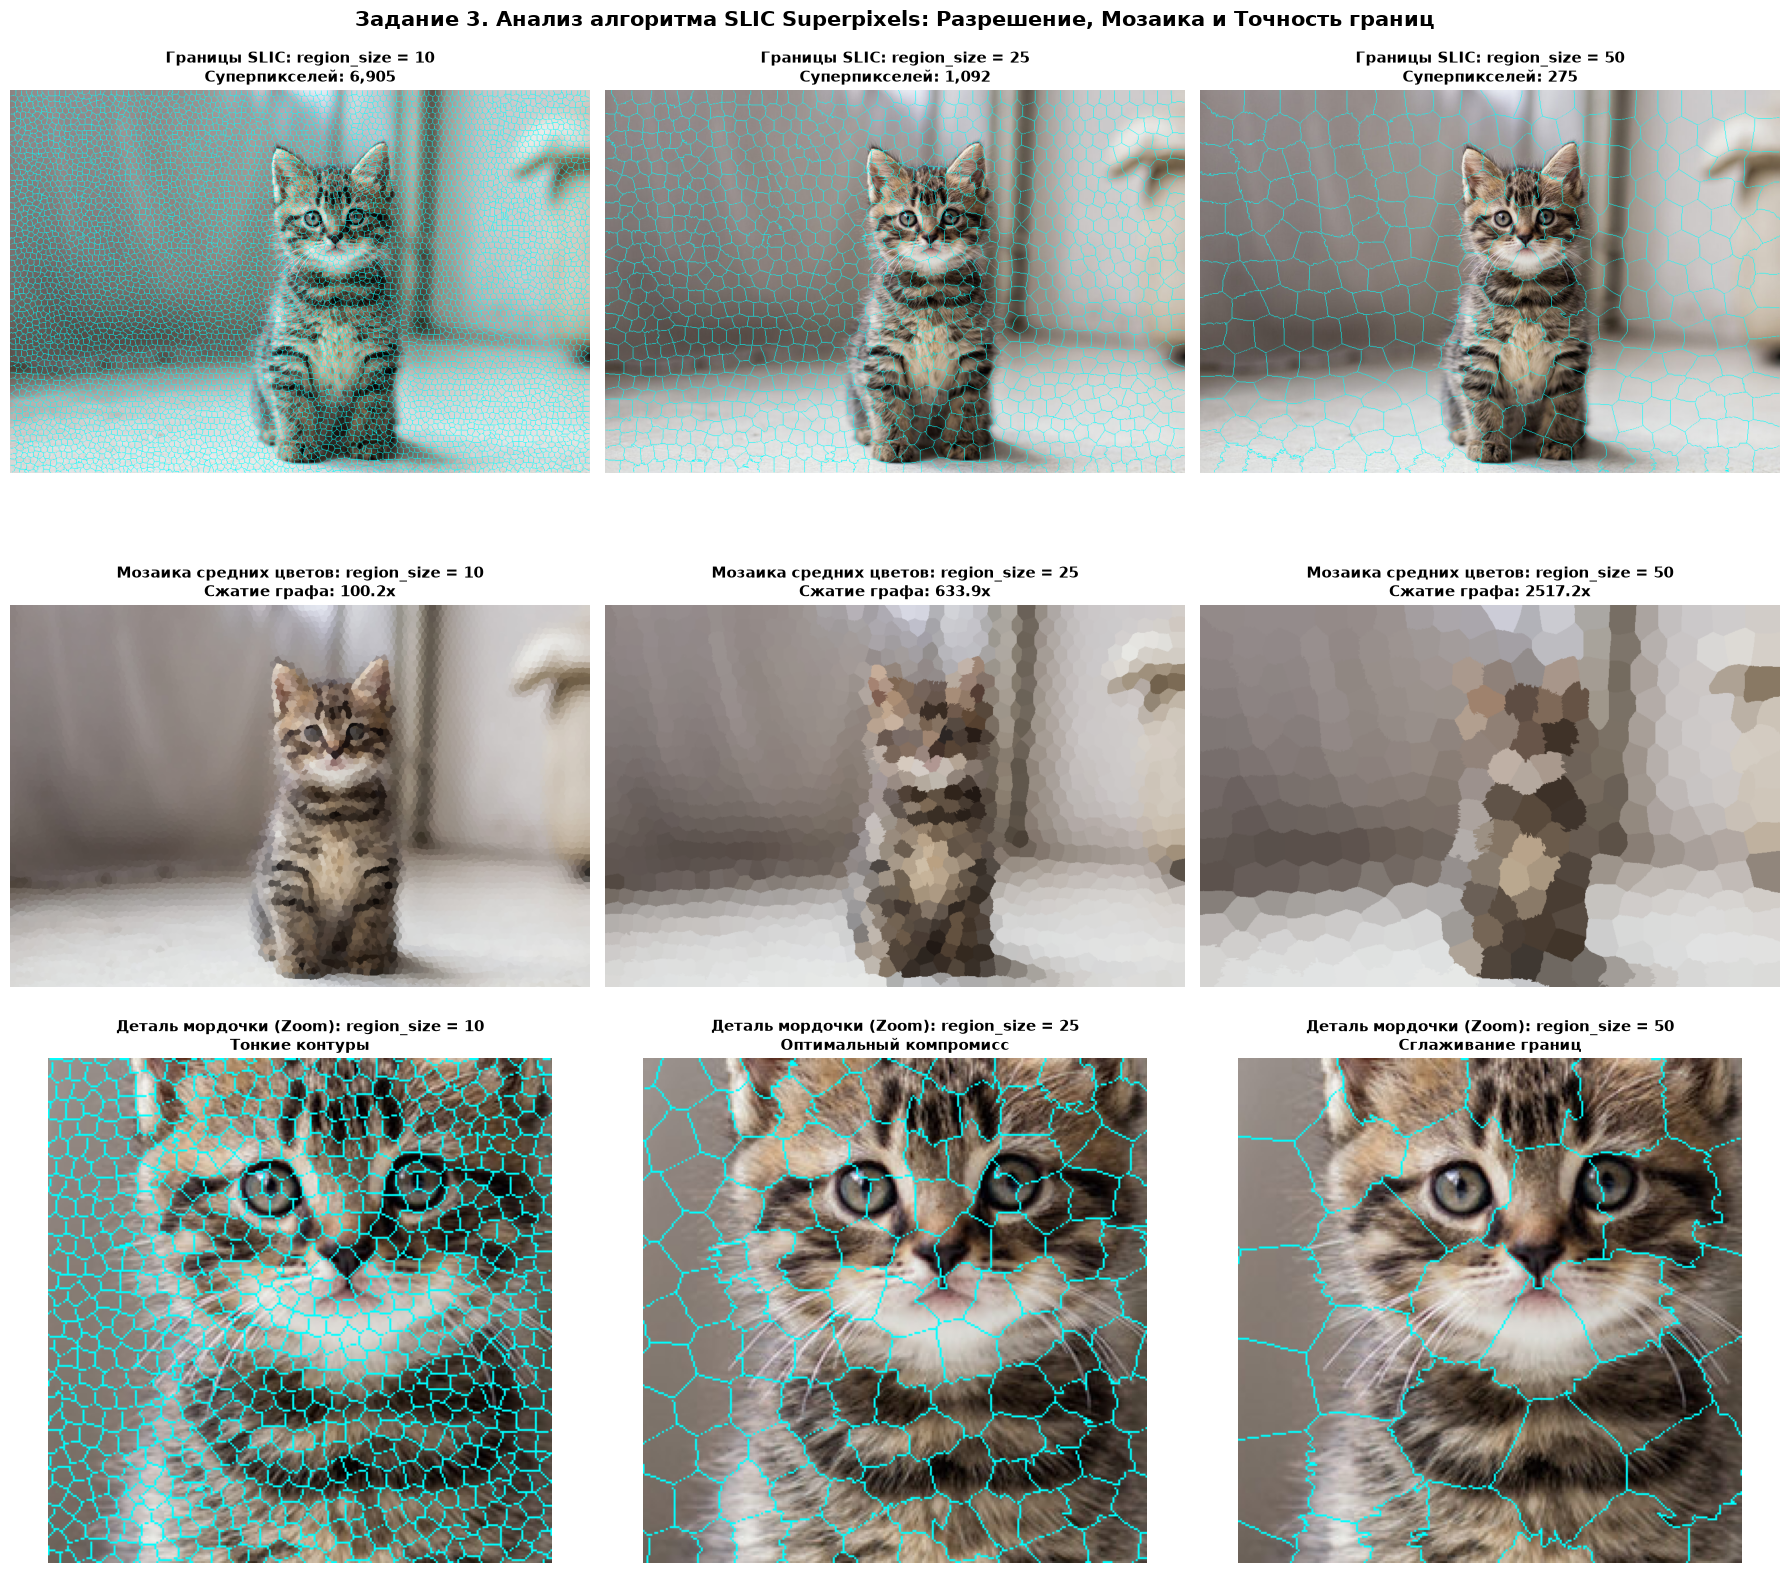

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(18, 16))

ymin, ymax = 160, 420
xmin, xmax = 420, 680

# Ряд 1: Контуры суперпикселей
for idx, r_size in enumerate(region_sizes):
    exp = slic_experiments[r_size]
    axes[0, idx].imshow(exp['contours_img'])
    axes[0, idx].set_title(f"Границы SLIC: region_size = {r_size}\nСуперпикселей: {exp['num_sp']:,}", fontweight='bold')
    axes[0, idx].axis('off')

# Ряд 2: Мозаика средних цветов
for idx, r_size in enumerate(region_sizes):
    exp = slic_experiments[r_size]
    axes[1, idx].imshow(exp['mosaic'])
    axes[1, idx].set_title(f"Мозаика средних цветов: region_size = {r_size}\nСжатие графа: {exp['compression']:.1f}x", fontweight='bold')
    axes[1, idx].axis('off')

# Ряд 3: Zoom In на мордочку
for idx, r_size in enumerate(region_sizes):
    exp = slic_experiments[r_size]
    roi_contour = exp['contours_img'][ymin:ymax, xmin:xmax]
    axes[2, idx].imshow(roi_contour)
    axes[2, idx].set_title(f"Деталь мордочки (Zoom): region_size = {r_size}\n{'Тонкие контуры' if r_size==10 else ('Оптимальный компромисс' if r_size==25 else 'Сглаживание границ')}", fontweight='bold')
    axes[2, idx].axis('off')

plt.suptitle("Задание 3. Анализ алгоритма SLIC Superpixels: Разрешение, Мозаика и Точность границ", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


**Вывод по Заданию 3 и компромиссу параметров:**
- **Компромисс между скоростью и точностью:**
  - При `region_size = 10` суперпиксели очень точно обтекают контуры зрачков, усов и шерстинок, но их число велико (6 905 шт.), давая сжатие в ~100 раз.
  - При `region_size = 50` суперпикселей всего 275 шт. (сжатие в 2 517 раз), но крупные полигоны неизбежно срезают острые углы и объединяют шерсть с фоном.
  - `region_size = 25` представляет собой **идеальный инженерный баланс**: размерность графа падает в 634 раза (с 692 тыс. до 1 092 узлов), при этом силуэт объекта и резкие перепады яркости сохраняются практически безупречно.
- **Оценка снижения сложности:**
  Для алгоритмов разреза графа со сложностью $O(V \cdot E)$ переход от пиксельной решетки ($V \approx 7 \cdot 10^5$, $E \approx 2.8 \cdot 10^6$) к суперпиксельному графу ($V \approx 10^3$, $E \approx 4 \cdot 10^3$) сокращает число операций более чем в $10^5$ раз, превращая многосекундный расчет в работу в реальном времени (Real-Time).


---
## Контрольные вопросы для защиты лабораторной работы

### Вопрос 1. Почему для Watershed в качестве «рельефа» используют градиент яркости, а не саму яркость напрямую?
**Ответ:**
В алгоритме Watershed разделяющие гребни («плотины») должны формироваться вдоль физических границ объектов. Сама по себе интенсивность (яркость) внутри объекта неоднородна из-за теней, текстуры и бликов. Если использовать яркость напрямую, плотины будут возводиться по уровням освещенности внутри однородных областей, порождая колоссальную избыточную сегментацию (over-segmentation). 
Модуль градиента яркости $|\nabla I(x, y)|$ отражает скорость изменения цвета: он минимален внутри объектов (низины рельефа) и формирует выраженные хребты ровно на контрастных границах перепада цветов. В случае бинарных соприкасающихся фигур рельефом выступает инвертированная карта расстояний (Distance Transform), где геометрические центры тел соответствуют глубочайшим впадинам.

---

### Вопрос 2. Что произойдёт с результатом Watershed, если маркер объекта поставлен не по центру, а ближе к его краю?
**Ответ:**
1. **Риск прорыва («утечки») бассейна:** Вблизи края объекта барьер градиента может быть локально слабее или уже. Вода от смещенного маркера способна перелиться за физический контур раньше, чем успеет равномерно заполнить тело самого объекта.
2. **Асимметрия и смещение делящей границы:** Волновые фронты распространяются во все стороны. Если маркер одного объекта расположен у контактной границы, а маркер второго — по центру, вода от первого маркера достигнет перемычки существенно раньше и искусственно «вытолкнет» водораздел вглубь соседнего объекта, нарушая симметрию разделения.

---

### Вопрос 3. Почему задача разреза графа минимальной стоимости эквивалентна задаче о максимальном потоке — в чём интуиция этой связи?
**Ответ:**
Эквивалентность доказана фундаментальной **теоремой Форда–Фалкерсона (Max-Flow Min-Cut Theorem)**.
*Интуиция:* Представим граф изображения как гидравлическую систему водопроводных труб, соединяющих Источник $S$ (Объект) и Сток $T$ (Фон), где пропускная способность каждой трубы равна весу ребра (степени цветового сходства соседних пикселей).
Предельный объем потока жидкости, который в принципе можно прокачать через такую сеть от $S$ к $T$, лимитируется самым узким «бутылочным горлышком» (bottleneck) системы. Если перерезать трубы именно в этом месте наименьшей суммарной емкости (минимальный разрез), сообщение между $S$ и $T$ полностью прервется. 
В сегментации похожие соседние пиксели соединены «толстыми трубами» (высокий штраф за разрез), а контрастные пиксели на границе объекта и фона — «тонкими трубами» (низкий вес). Алгоритм минимального разреза математически рассекает сеть именно по тонким трубам, прокладывая границу строго по истинным очертаниям объекта.

---

### Вопрос 4. Что произойдёт с результатом GrabCut, если исходный прямоугольник пользователя частично обрежет объект?
**Ответ:**
Часть объекта, оставшаяся за пределами прямоугольника, будет **безвозвратно потеряна и помечена как фон**.
*Причины:*
1. При инициализации `GC_INIT_WITH_RECT` все пиксели строго снаружи рамки получают жесткий статус `GC_BGD` (100% фоновый терминал). Вес ребра к фоновому стоку принимается бесконечным ($\infty$), и итерации Graph Cut никогда не пересматривают их принадлежность (оптимизируются только пиксели внутри рамки со статусом `GC_PR_FGD` и `GC_PR_BGD`).
2. Отрезанные пиксели объекта, попав в категорию фона, участвуют в построении фоновой смеси гауссиан ($GMM_{bgd}$). Алгоритм ошибочно принимает цвета объекта за фон и может «проесть» дыры даже внутри оставшейся части объекта в рамке.

---

### Вопрос 5. Почему в формуле расстояния SLIC используется цветовое пространство Lab, а не RGB?
**Ответ:**
Цветовое пространство **CIELAB является перцептивно равномерным** (*perceptually uniform*). В нем геометрическое евклидово расстояние:
$$D_{lab} = \sqrt{(\Delta L)^2 + (\Delta a)^2 + (\Delta b)^2}$$
строго пропорционально величине цветового контраста, воспринимаемой физиологией глаза человека (метрика $\Delta E$). 
В пространстве RGB каналы сильно скоррелированы, а чувствительность зрения к зеленому, красному и синему компонентам радикально различается. Кластеризация в RGB порождала бы искаженные суперпиксели, слабо согласованные с визуальными границами.

---

### Вопрос 6. Как параметр region_size в SLIC влияет на компромисс между скоростью обработки и точностью повторения истинных границ объектов?
**Ответ:**
* При малом `region_size` (10 px): генерируется огромное количество мелких суперпикселей. Алгоритм с высокой точностью огибает тонкие структуры, острые углы и изогнутые границы (высокий *Boundary Recall*, минимальная ошибка *Under-segmentation*). Платой за это является большее время работы и малый коэффициент сжатия.
* При большом `region_size` (50 px): суперпиксели крупные, их число минимально. Достигается колоссальное сжатие (в тысячи раз), ускоряющее последующие методы на порядки. Однако крупные полигоны сглаживают углы, срезают детали и захватывают в один суперпиксель пиксели разных цветов.

---

### Вопрос 7. Superpixels называют «промежуточным», а не финальным результатом сегментации — почему это так и в каких задачах они применяются именно в этой роли?
**Ответ:**
* **Почему промежуточный:** Суперпиксели осуществляют избыточную сегментацию (*over-segmentation*). Они не несут семантического смысла (не выделяют класс «автомобиль» или «человек»), а служат для агрегации миллионов сырых пикселей в несколько сотен топологически однородных полигонов, заменяя жесткую матричную решетку на адаптивный граф смежности.
* **Где применяются:**
  1. *Интерактивная сегментация:* Построение Graph Cut / GrabCut над суперпикселями вместо пикселей ускоряет вычисления в тысячи раз, обеспечивая отклик 30+ FPS.
  2. *Оптический поток и стереозрение:* Сопоставление блоков суперпикселей устойчиво к шуму и решает проблему неоднозначности апертуры.
  3. *Генерация кандидатов на объекты:* Алгоритм Selective Search в детекторах R-CNN иерархически объединяет схожие суперпиксели в bounding boxes.
  4. *Анализ гиперспектральных снимков:* Ускорение классификации почв и растительности на космических снимках высокого разрешения.
